# SEED-SD Veri Seti Yapı İncelemesi

Bu notebook, model eğitimine başlamadan önce SEED-SD veri setinin fiziksel yapısını ve özellik (feature) şemasını incelemek amacıyla hazırlanmıştır.

## 1. Proje Kurulumu

Bu bölümde proje yardımcı fonksiyonları yüklenmekte ve SEED-SD veri seti yolunun doğru şekilde yapılandırıldığı doğrulanmaktadır.

In [8]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("D:/ReLF")
sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import DEFAULT_CONFIG_PATH, get_dataset_root

print(DEFAULT_CONFIG_PATH)

dataset_root = get_dataset_root()
dataset_root

D:\ReLF\configs\paths.yaml


WindowsPath('D:/SEED-SD')

## 2. Veri Setinin Üst Düzey Yapısı

SEED-SD veri seti;

- meta veri dosyaları,
- önceden çıkarılmış EEG özellikleri,
- önceden çıkarılmış göz hareketi özellikleri,
- ham EEG kayıtları,
- ham göz hareketi kayıtları

içermektedir.

In [9]:
for item in sorted(dataset_root.iterdir()):
    item_type = "DIR" if item.is_dir() else "FILE"
    print(f"[{item_type}] {item.name}")

[FILE] channel-order.xlsx
[FILE] channel_62_pos.locs
[DIR] eeg_features
[DIR] eeg_raw
[DIR] eye_features
[DIR] eye_raw
[FILE] SEED-SD_stimulation.xlsx


Veri setinin üst düzey yapısı incelendiğinde hem ön işlenmiş özelliklerin (feature) hem de ham sinyallerin (raw signals) sağlandığı görülmektedir.

Bu çalışmanın ilk aşamasında ReLF makalesindeki deney düzenini yeniden üretmek amacıyla `eeg_features` ve `eye_features` dizinleri kullanılacaktır.

In [10]:
import pandas as pd

rows = []

for item in sorted(dataset_root.iterdir()):
    rows.append({
        "name": item.name,
        "type": "directory" if item.is_dir() else "file",
        "path": str(item)
    })

top_level_df = pd.DataFrame(rows)
top_level_df    

,name,type,path
0,channel-order.xlsx,file,D:\SEED-SD\channel-order.xlsx
1,channel_62_pos.locs,file,D:\SEED-SD\channel_62_pos.locs
2,eeg_features,directory,D:\SEED-SD\eeg_features
3,eeg_raw,directory,D:\SEED-SD\eeg_raw
4,eye_features,directory,D:\SEED-SD\eye_features
5,eye_raw,directory,D:\SEED-SD\eye_raw
6,SEED-SD_stimulation.xlsx,file,D:\SEED-SD\SEED-SD_stimulation.xlsx


## 3. Özellik (Feature) Klasör Yapısının İncelenmesi

Bu bölümde EEG ve göz hareketi özelliklerinin klasör organizasyonu incelenmektedir.

In [11]:
for feature_dir in ["eeg_features", "eye_features"]:
    path = dataset_root / feature_dir
    print(f"\n{feature_dir}")
    for item in sorted(path.iterdir()):
        print(f" - {item.name}")


eeg_features
 - session_1
 - session_2
 - session_3

eye_features
 - session_1
 - session_2
 - session_3


### İlk Gözlemler

İnceleme sonucunda hem EEG hem de göz hareketi özelliklerinin üç ayrı oturum (session) altında saklandığı görülmüştür.

Her iki modalite de aşağıdaki yapıyı takip etmektedir:

- session_1
- session_2
- session_3

Bu durum veri setinin farklı uyku koşullarına ait deney kayıtlarını ayrı oturumlar halinde organize ettiğini göstermektedir.

Bir sonraki aşamada her oturum içerisindeki katılımcı (subject) dosyaları incelenecektir.

## 4. Oturum ve Katılımcı Yapısının İncelenmesi

In [12]:
sessions = sorted((dataset_root / "eeg_features").iterdir())

for session in sessions:
    subject_files = list (session.glob("*.npy"))

    print(f"{session.name}")
    print(f"Katılımcı sayısı: {len(subject_files)}")
    print("-" * 40)

session_1
Katılımcı sayısı: 40
----------------------------------------
session_2
Katılımcı sayısı: 40
----------------------------------------
session_3
Katılımcı sayısı: 40
----------------------------------------


## 5. Clip Uzunluklarının İncelenmesi

Bu bölümde bir katılımcıya ait tüm kliplerin pencere (window) sayıları incelenmektedir.

Amaç, farklı video kliplerin içerdiği zaman penceresi sayılarının dağılımını anlamaktır.

In [13]:
import numpy as np
import pandas as pd

sample_file = (
    dataset_root
    / "eeg_features"
    / "session_1"
    / "sub10_20200903.npy"
)

data = np.load(sample_file, allow_pickle=True).item()

clip_lengths = []

for clip_name, clip_array in data.items():

    clip_lengths.append({
        "clip": clip_name,
        "window_count": clip_array.shape[0]
    })

clip_df = pd.DataFrame(clip_lengths)

clip_df.head()

,clip,window_count
0,clip_1,42
1,clip_2,17
2,clip_3,49
3,clip_4,32
4,clip_5,22


In [14]:
clip_df["window_count"].describe()

count    24.000000
mean     35.125000
std      13.260968
min      12.000000
25%      27.750000
50%      35.500000
75%      42.250000
max      64.000000
Name: window_count, dtype: float64

### Bulgular

Örnek olarak incelenen bir katılımcıya ait EEG özellik dosyasında toplam 24 video klibi bulunmaktadır.

Klip başına düşen pencere (window) sayıları değişkenlik göstermektedir.

Özet istatistikler:

- Ortalama pencere sayısı: 35.13
- Standart sapma: 13.26
- Minimum pencere sayısı: 12
- Maksimum pencere sayısı: 64

Bu sonuçlar, veri setindeki video kliplerin farklı uzunluklara sahip olduğunu göstermektedir.

### Yorum

Klip uzunluklarının değişken olması, veri setinin sabit uzunluklu örneklerden oluşmadığını göstermektedir.

Bu durum ilerleyen aşamalarda veri yükleyici (DataLoader) tasarımı sırasında dikkate alınmalıdır.

Özellikle Transformer tabanlı modellerde farklı uzunluktaki dizilerin (sequence) aynı batch içerisinde kullanılabilmesi için padding ve masking stratejileri gerekebilir.

Bu nedenle veri setinin pencere uzunluğu dağılımı, model geliştirme aşamasında önemli bir tasarım girdisi olacaktır.

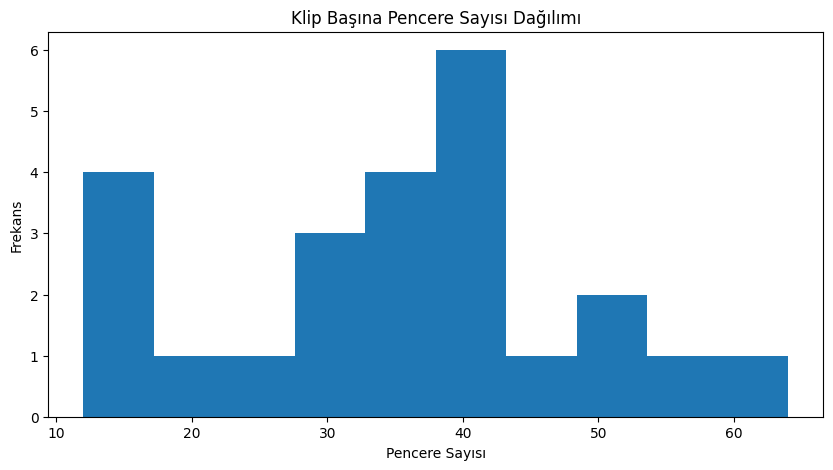

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    clip_df["window_count"],
    bins=10
)

plt.title("Klip Başına Pencere Sayısı Dağılımı")
plt.xlabel("Pencere Sayısı")
plt.ylabel("Frekans")

plt.show()

## 6. Tüm Veri Seti Üzerindeki Pencere Sayısı Analizi

Bu bölümde yalnızca tek bir katılımcı değil, tüm veri seti incelenmektedir.

Her satır bir klibi temsil etmektedir.

Toplam:

- 3 oturum (session)
- 40 katılımcı
- 24 klip

üzerinden elde edilen tüm pencere sayıları analiz edilmektedir.

In [16]:
from src.data.inspect_dataset import collect_dataset_window_statistics

rows = collect_dataset_window_statistics()

stats_df = pd.DataFrame(rows)

stats_df.head()


,session,subject_file,subject_id,clip,window_count,feature_shape
0,session_1,sub10_20200903.npy,sub10,clip_1,42,"(5, 62)"
1,session_1,sub10_20200903.npy,sub10,clip_2,17,"(5, 62)"
2,session_1,sub10_20200903.npy,sub10,clip_3,49,"(5, 62)"
3,session_1,sub10_20200903.npy,sub10,clip_4,32,"(5, 62)"
4,session_1,sub10_20200903.npy,sub10,clip_5,22,"(5, 62)"


In [17]:
stats_df.shape

(2880, 6)

In [18]:
stats_df.describe()

,window_count
count,2880.000000
mean,33.958333
std,12.847936
min,10.000000
25%,23.750000
50%,35.500000
75%,44.000000
max,64.000000


In [19]:
stats_df["window_count"].describe()

count    2880.000000
mean       33.958333
std        12.847936
min        10.000000
25%        23.750000
50%        35.500000
75%        44.000000
max        64.000000
Name: window_count, dtype: float64

### Bulgular

Tüm veri seti üzerinde yapılan analiz sonucunda toplam 2880 klip gözlemi elde edilmiştir.

Bu sayı aşağıdaki yapıya karşılık gelmektedir:

- 3 session
- 40 subject
- 24 clip

Özet istatistikler:

- Toplam klip sayısı: 2880
- Ortalama pencere sayısı: 33.96
- Medyan pencere sayısı: 35.50
- Standart sapma: 12.85
- Minimum pencere sayısı: 10
- Maksimum pencere sayısı: 64

### Yorum

Sonuçlar, SEED-SD veri setindeki kliplerin sabit uzunlukta olmadığını göstermektedir.

Pencere sayıları 10 ile 64 arasında değişmektedir.

Bu durum veri setinin değişken uzunluklu zaman serilerinden oluştuğunu göstermektedir.

İlerleyen aşamalarda Transformer tabanlı ReLF mimarisi uygulanırken sequence padding ve attention masking mekanizmalarının önemli rol oynayacağı öngörülmektedir.

Ayrıca ortalama ve medyan değerlerinin birbirine oldukça yakın olması, dağılımın aşırı derecede çarpık olmadığını göstermektedir.

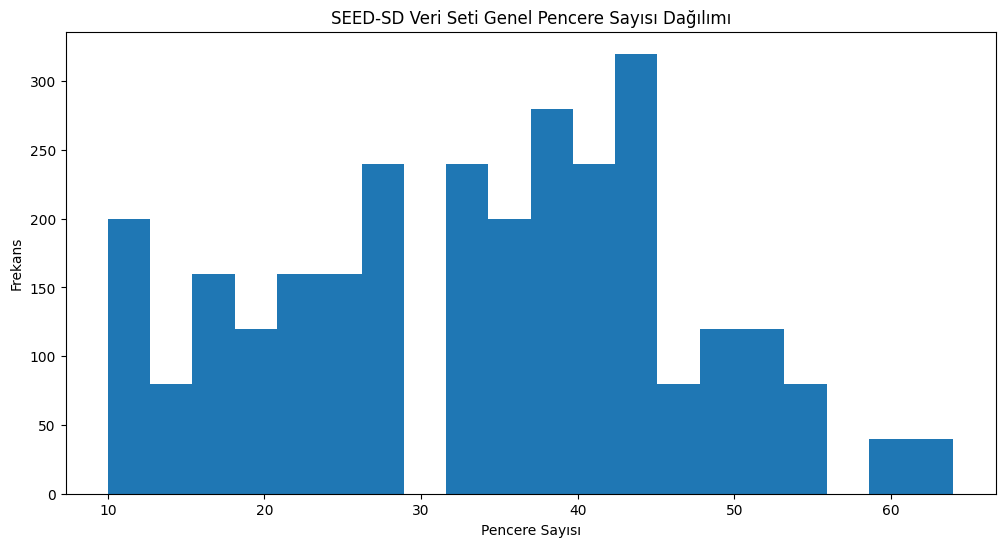

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.hist(
    stats_df["window_count"],
    bins=20
)

plt.title("SEED-SD Veri Seti Genel Pencere Sayısı Dağılımı")
plt.xlabel("Pencere Sayısı")
plt.ylabel("Frekans")

plt.show()

### Histogram Yorumu

Tüm veri seti üzerinde elde edilen histogram incelendiğinde pencere sayılarının yaklaşık olarak 30–45 aralığında yoğunlaştığı görülmektedir.

Dağılımın aşırı derecede çarpık olmadığı ve çok büyük uç değerler içermediği gözlemlenmiştir.

Bununla birlikte minimum ve maksimum değerler arasında önemli bir fark bulunmaktadır (10–64).

Bu durum veri setinin değişken uzunluklu zaman serilerinden oluştuğunu doğrulamaktadır.

In [21]:
session_summary = (
    stats_df
    .groupby("session")["window_count"]
    .mean()
    .reset_index()
)
session_summary

,session,window_count
0,session_1,35.125000
1,session_2,34.666667
2,session_3,32.083333


### Session Karşılaştırması

Üç oturum arasında pencere sayıları açısından küçük farklılıklar bulunmaktadır.

- Session 1: 35.13
- Session 2: 34.67
- Session 3: 32.08

Session 3'te ortalama pencere sayısının bir miktar daha düşük olduğu görülmektedir.

Ancak oturumlar arasında dramatik bir fark bulunmamaktadır.

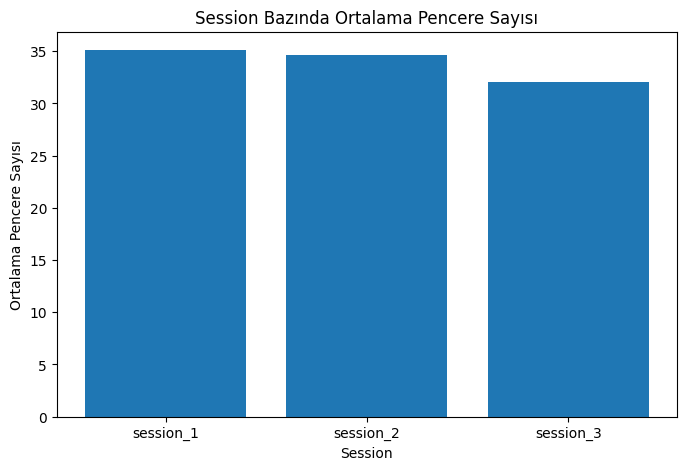

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(
    session_summary["session"],
    session_summary["window_count"]
)

plt.title("Session Bazında Ortalama Pencere Sayısı")
plt.xlabel("Session")
plt.ylabel("Ortalama Pencere Sayısı")

plt.show()

## 7. Klip Bazında Pencere Sayısı Analizi

Bu bölümde 24 farklı video klibin ortalama pencere sayıları karşılaştırılmaktadır.

Amaç, belirli kliplerin sistematik olarak daha uzun veya daha kısa olup olmadığını incelemektir.

In [23]:
import pandas as pd

stats_df = pd.read_csv("D:/ReLF/data/reports/window_statistics.csv")

stats_df.head()

,session,subject_file,subject_id,clip,window_count,feature_shape
0,session_1,sub10_20200903.npy,sub10,clip_1,42,"(5, 62)"
1,session_1,sub10_20200903.npy,sub10,clip_2,17,"(5, 62)"
2,session_1,sub10_20200903.npy,sub10,clip_3,49,"(5, 62)"
3,session_1,sub10_20200903.npy,sub10,clip_4,32,"(5, 62)"
4,session_1,sub10_20200903.npy,sub10,clip_5,22,"(5, 62)"


In [24]:
stats_df.shape

(2880, 6)

In [25]:
clip_summary = (
    stats_df
    .groupby("clip", as_index=False)["window_count"]
    .mean()
    .sort_values("window_count", ascending=False)
)

clip_summary

,clip,window_count
0,clip_1,46.333333
6,clip_15,45.333333
4,clip_13,43.000000
10,clip_19,41.666667
19,clip_5,41.000000
2,clip_11,41.000000
22,clip_8,40.333333
18,clip_4,37.666667
14,clip_22,36.666667
9,clip_18,36.666667


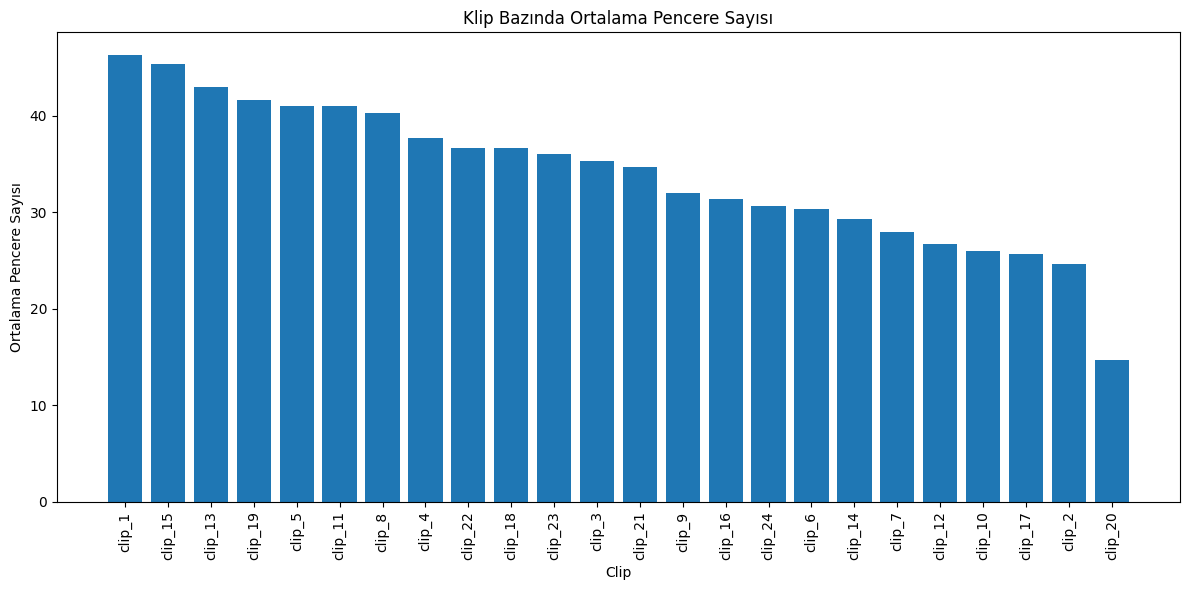

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    clip_summary["clip"],
    clip_summary["window_count"]
)

plt.title("Klip Bazında Ortalama Pencere Sayısı")
plt.xlabel("Clip")
plt.ylabel("Ortalama Pencere Sayısı")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Bulgular

Klipler arasında ortalama pencere sayıları açısından belirgin farklılıklar bulunmaktadır.

En uzun klipler:

- clip_1 → 46.33
- clip_15 → 45.33
- clip_13 → 43.00

En kısa klipler:

- clip_20 → 14.67
- clip_2 → 24.67
- clip_17 → 25.67

Sonuçlar, veri setindeki tüm video kliplerin aynı uzunlukta olmadığını göstermektedir.

### Yorum

Klip bazında gözlenen farklılıklar sistematik görünmektedir.

Bazı klipler tüm katılımcılar ve tüm oturumlar boyunca sürekli olarak daha fazla pencere üretirken bazı klipler daha kısa kalmaktadır.

Bu durumun temel nedeni büyük olasılıkla video klip sürelerinin farklı olmasıdır.

Bir sonraki aşamada uyarıcı (stimulus) dosyası incelenerek her klibin deney tasarımındaki rolü ve duygusal etiketi analiz edilecektir.

## 8. Deney Uyarıcılarının (Stimuli) İncelenmesi

In [28]:
stimulus_path = dataset_root / "SEED-SD_stimulation.xlsx"

stimulus_path

WindowsPath('D:/SEED-SD/SEED-SD_stimulation.xlsx')

In [29]:
stimulus_df = pd.read_excel(stimulus_path)

stimulus_df.head()

,Name of the clip,Label,Source url,Start time point,End time point,Note
0,Black Keys/半音,1.0,http://www.le.com/ptv/vplay/20136697.html?ch=d...,42:32,45:41,NaN
1,The Eye 3/见鬼10,2.0,https://v-wb.youku.com/v_show/id_XMTU0MzQwMjIw...,"2 days, 1:25:00","2 days, 3:00:00","We can't find the authorized copies, so we pr..."
2,Rob-B-Hood/宝贝计划,3.0,https://v.qq.com/x/cover/ruex4wk8ynvxxkx/j0012...,"1 day, 17:07:00",45:06,NaN
3,A Bite of China/舌尖上的中国,0.0,https://v.youku.com/v_show/id_XNzEwMDQ2MTk2.ht...,30:29,32:48,NaN
4,The Child's Eye/童眼,2.0,https://v.qq.com/x/cover/foojcpwv9xwy1cf/p0015...,41:00,42:37,NaN


## 9. Duygu Etiketlerinin İncelenmesi

In [30]:
stimulus_df["Label"].value_counts().sort_index()

Label
0.0    6
1.0    6
2.0    6
3.0    6
Name: count, dtype: int64

In [31]:
stimulus_df["Label"].unique()

array([ 1.,  2.,  3.,  0., nan])

In [32]:
stimulus_df.shape

(26, 6)

In [34]:
stimulus_df

,Name of the clip,Label,Source url,Start time point,End time point,Note
0,Black Keys/半音,1.0,http://www.le.com/ptv/vplay/20136697.html?ch=d...,42:32,45:41,NaN
1,The Eye 3/见鬼10,2.0,https://v-wb.youku.com/v_show/id_XMTU0MzQwMjIw...,"2 days, 1:25:00","2 days, 3:00:00","We can't find the authorized copies, so we pr..."
2,Rob-B-Hood/宝贝计划,3.0,https://v.qq.com/x/cover/ruex4wk8ynvxxkx/j0012...,"1 day, 17:07:00",45:06,NaN
3,A Bite of China/舌尖上的中国,0.0,https://v.youku.com/v_show/id_XNzEwMDQ2MTk2.ht...,30:29,32:48,NaN
4,The Child's Eye/童眼,2.0,https://v.qq.com/x/cover/foojcpwv9xwy1cf/p0015...,41:00,42:37,NaN
5,A Bite of China/舌尖上的中国,0.0,https://v.youku.com/v_show/id_XNzE2MTY5MDIw.ht...,05:19:00,08:05:00,NaN
6,A Bite of China/舌尖上的中国,0.0,https://v.youku.com/v_show/id_XNzE2MTY5MDIw.ht...,24:42,26:41,NaN
7,Very Happy/我家有喜 EP32,1.0,https://v.youku.com/v_show/id_XNDYzMTU5MzIw.ht...,17:09:00,21:13:00,NaN
8,A Bite of China /舌尖上的中国,0.0,https://v.youku.com/v_show/id_XNzE5NTM5Mjky.ht...,31:18,33:44,NaN
9,A Wedding Invitation/分手合约,1.0,https://v.youku.com/v_show/id_XMjgyODUzMjA3Mg=...,01:34:04,01:38:50,NaN


In [35]:
stimulus_df["Label"].isna().sum()

np.int64(2)

In [36]:
stimulus_df[stimulus_df["Label"].isna()]

,Name of the clip,Label,Source url,Start time point,End time point,Note
24,NaN,NaN,NaN,NaN,NaN,NaN
25,"(Label) 0: neutral, 1: sad, 2: fear, 3: happy",NaN,NaN,NaN,NaN,NaN


### Duygu Etiketi Eşlemesi

SEED-SD veri setinde kullanılan duygu etiketleri aşağıdaki gibidir:

| Label | Emotion |
|---------|---------|
| 0 | Neutral |
| 1 | Sad |
| 2 | Fear |
| 3 | Happy |

Veri seti dört sınıflı bir duygu tanıma problemi olarak tasarlanmıştır.

### Sınıf Dağılımı

Her duygu sınıfı veri setinde tam olarak 6 video klip ile temsil edilmektedir.

Bu durum deney tasarımının dengeli (balanced) olduğunu göstermektedir.

Dolayısıyla veri seti seviyesinde sınıf dengesizliği (class imbalance) problemi bulunmamaktadır.

In [38]:
stimulus_clean = stimulus_df.dropna(subset=["Label"]).copy()

stimulus_clean.shape

(24, 6)

In [40]:
stimulus_clean[["Name of the clip", "Label"]]

,Name of the clip,Label
0,Black Keys/半音,1.0
1,The Eye 3/见鬼10,2.0
2,Rob-B-Hood/宝贝计划,3.0
3,A Bite of China/舌尖上的中国,0.0
4,The Child's Eye/童眼,2.0
5,A Bite of China/舌尖上的中国,0.0
6,A Bite of China/舌尖上的中国,0.0
7,Very Happy/我家有喜 EP32,1.0
8,A Bite of China /舌尖上的中国,0.0
9,A Wedding Invitation/分手合约,1.0


In [43]:
label_map = {
    0:"Neutral",
    1: "Sad",
    2: "Fear",
    3: "Happy"
}

stimulus_clean["Emotion"] = (
    stimulus_clean["Label"]
    .map(label_map)
)

stimulus_clean[
    ["Name of the clip", "Label", "Emotion"]
]

,Name of the clip,Label,Emotion
0,Black Keys/半音,1.0,Sad
1,The Eye 3/见鬼10,2.0,Fear
2,Rob-B-Hood/宝贝计划,3.0,Happy
3,A Bite of China/舌尖上的中国,0.0,Neutral
4,The Child's Eye/童眼,2.0,Fear
5,A Bite of China/舌尖上的中国,0.0,Neutral
6,A Bite of China/舌尖上的中国,0.0,Neutral
7,Very Happy/我家有喜 EP32,1.0,Sad
8,A Bite of China /舌尖上的中国,0.0,Neutral
9,A Wedding Invitation/分手合约,1.0,Sad


## 10. Klip Sıralaması ve Duygu Yapısının İncelenmesi

In [45]:
stimulus_clean = stimulus_clean.reset_index(drop=True)

stimulus_clean["clip_id"] = [
    f"clip_{i}"
    for i in range(1, len(stimulus_clean) + 1)
]

stimulus_clean[
    ["clip_id", "Name of the clip", "Emotion"]
]

,clip_id,Name of the clip,Emotion
0,clip_1,Black Keys/半音,Sad
1,clip_2,The Eye 3/见鬼10,Fear
2,clip_3,Rob-B-Hood/宝贝计划,Happy
3,clip_4,A Bite of China/舌尖上的中国,Neutral
4,clip_5,The Child's Eye/童眼,Fear
5,clip_6,A Bite of China/舌尖上的中国,Neutral
6,clip_7,A Bite of China/舌尖上的中国,Neutral
7,clip_8,Very Happy/我家有喜 EP32,Sad
8,clip_9,A Bite of China /舌尖上的中国,Neutral
9,clip_10,A Wedding Invitation/分手合约,Sad


### Klip ve Duygu Eşlemesi

Stimulus dosyasındaki sıralama kullanılarak her video klibi için `clip_id` oluşturulmuştur.

Bu eşleştirme sayesinde feature dosyalarında yer alan `clip_1`, `clip_2`, ..., `clip_24` anahtarları duygu etiketleriyle ilişkilendirilebilmektedir.

In [46]:
clip_label_df = stimulus_clean[
    ["clip_id", "Name of the clip", "Label", "Emotion"]
].copy()

In [47]:
clip_label_df.head()

,clip_id,Name of the clip,Label,Emotion
0,clip_1,Black Keys/半音,1.0,Sad
1,clip_2,The Eye 3/见鬼10,2.0,Fear
2,clip_3,Rob-B-Hood/宝贝计划,3.0,Happy
3,clip_4,A Bite of China/舌尖上的中国,0.0,Neutral
4,clip_5,The Child's Eye/童眼,2.0,Fear


In [49]:
stats_with_labels_df = stats_df.merge(
clip_label_df,
left_on="clip",
right_on="clip_id",
how="left"
)

In [50]:
stats_with_labels_df["Emotion"].isna().sum()

np.int64(0)

In [51]:
stats_with_labels_df["Emotion"].value_counts()

Emotion
Sad        720
Fear       720
Happy      720
Neutral    720
Name: count, dtype: int64

### Bulgular

Feature dosyaları ile stimulus etiketleri başarıyla eşleştirilmiştir.

Toplam 2880 gözlemin tamamı bir duygu etiketi ile ilişkilendirilmiştir.

Duygu sınıflarının dağılımı:

- Neutral: 720
- Sad: 720
- Fear: 720
- Happy: 720

### Yorum

SEED-SD veri seti hem stimulus seviyesinde hem de gözlem seviyesinde dengeli bir sınıf dağılımına sahiptir.

Bu durum model performansının sınıf dengesizliğinden etkilenmesini önlemektedir.

Dolayısıyla ilerleyen aşamalarda elde edilecek performans sonuçları daha güvenilir şekilde yorumlanabilecektir.